In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.preprocessing import LabelEncoder


Data Loading & Exploration



In [ ]:
df=pd.read_csv('/content/500_Person_Gender_Height_Weight_Index.csv')
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [175]:
df.head()

,Gender,Height,Weight,Index,BMI_Calc,WH_Ratio,Weight_x_Height,Weight_sq,Height_sq
0,1,174,96,4,31.708284,0.551724,16704,9216,30276
1,1,189,87,2,24.355421,0.460317,16443,7569,35721
2,0,185,110,4,32.140248,0.594595,20350,12100,34225
3,0,195,104,3,27.350427,0.533333,20280,10816,38025
4,1,149,61,3,27.476240,0.409396,9089,3721,22201


In [ ]:
df.shape

(500, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


Data Cleaning & Preprocessing

In [ ]:
df.duplicated().sum()

np.int64(11)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isna().sum()

,0
Gender,0
Height,0
Weight,0
Index,0


In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,Gender,Height,Weight,Index
0,1,174,96,4
1,1,189,87,2
2,0,185,110,4
3,0,195,104,3
4,1,149,61,3


Feature Engineering

In [ ]:
df['BMI_Calc'] = df['Weight'] / ((df['Height'] / 100) ** 2)

df['WH_Ratio'] = df['Weight'] / df['Height']


df['Weight_x_Height'] = df['Weight'] * df['Height']


df['Weight_sq'] = df['Weight'] ** 2
df['Height_sq'] = df['Height'] ** 2


Exploratory Data Analysis (EDA)

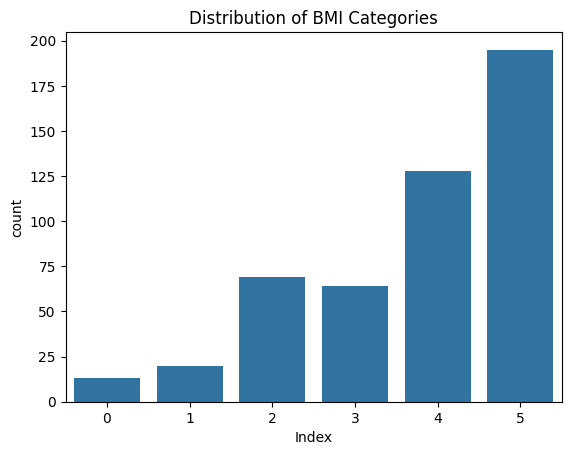

In [174]:
sns.countplot(x='Index', data=df)
plt.title("Distribution of BMI Categories")
plt.show()

array([[<Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Weight'}>],
       [<Axes: title={'center': 'Index'}>,
        <Axes: title={'center': 'BMI_Calc'}>,
        <Axes: title={'center': 'WH_Ratio'}>],
       [<Axes: title={'center': 'Weight_x_Height'}>,
        <Axes: title={'center': 'Weight_sq'}>,
        <Axes: title={'center': 'Height_sq'}>]], dtype=object)

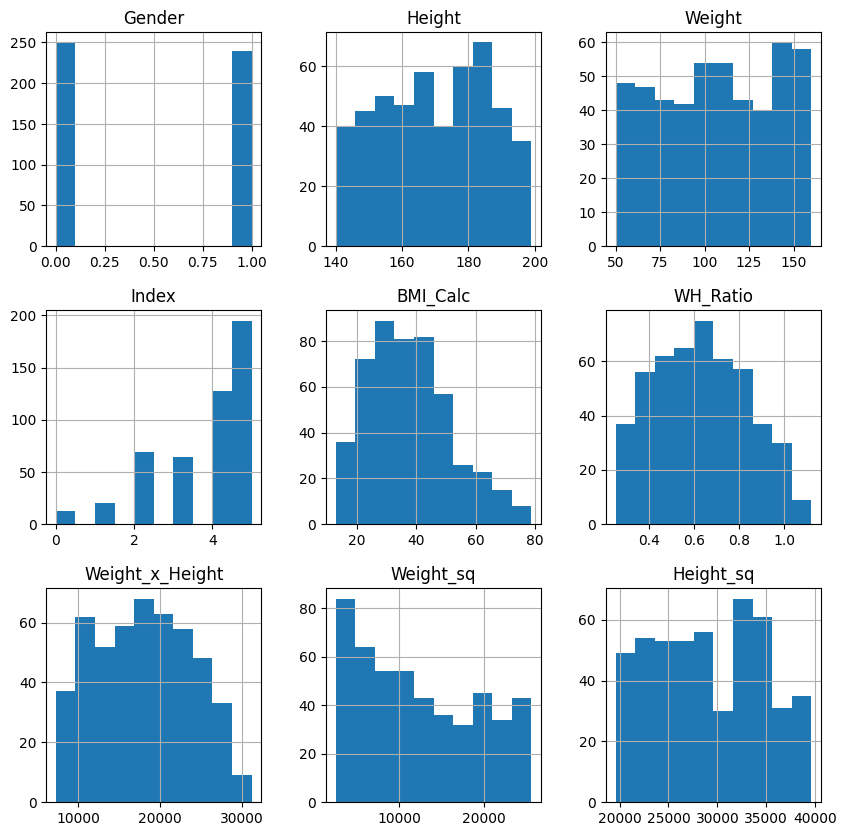

In [ ]:
df.hist(figsize=(10,10))

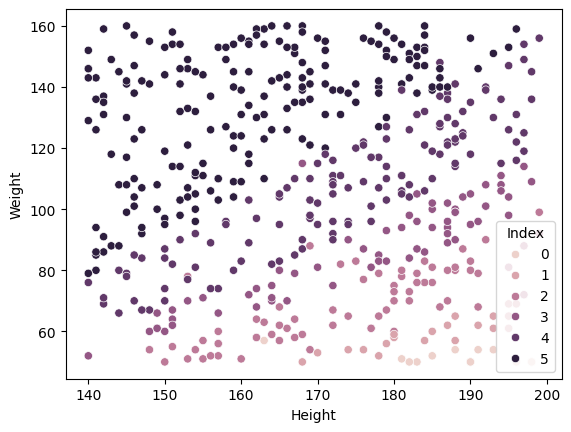

In [ ]:
sns.scatterplot(x='Height', y='Weight', hue='Index', data=df)
plt.show()

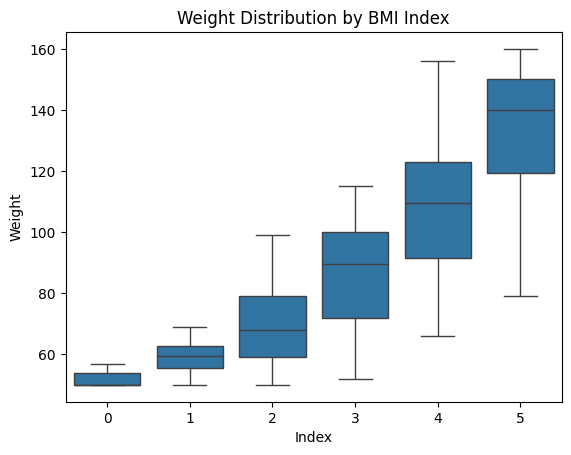

In [ ]:
sns.boxplot(x='Index', y='Weight', data=df)
plt.title("Weight Distribution by BMI Index")
plt.show()

<Axes: >

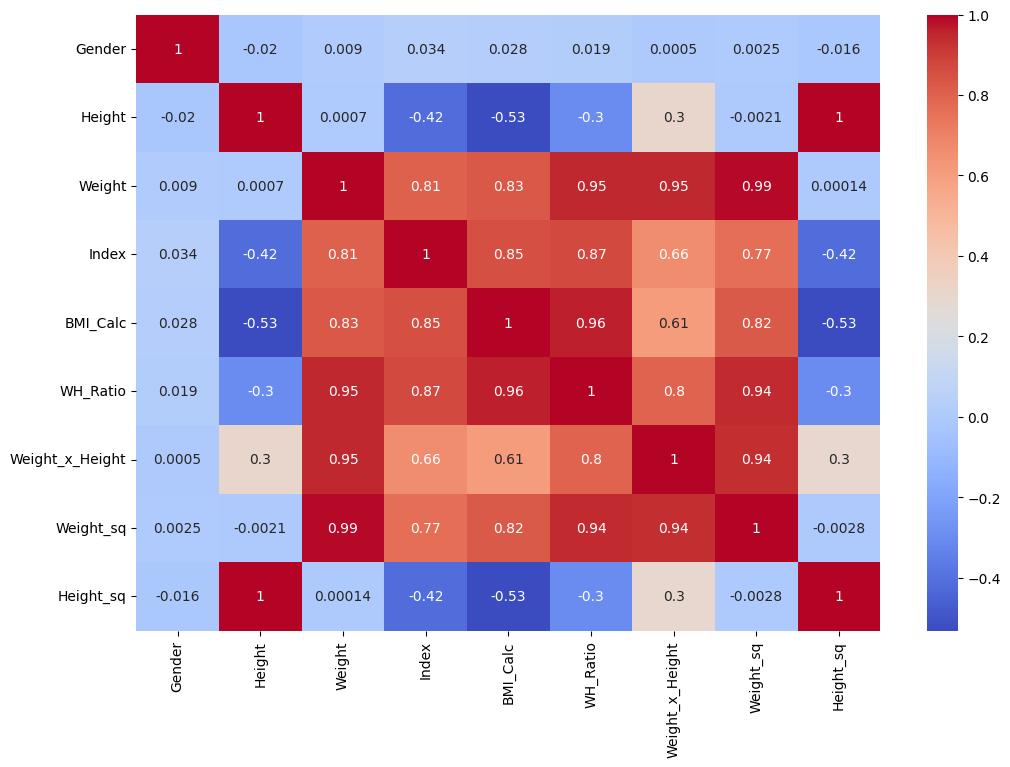

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

Data Splitting & Scaling

In [ ]:
x=df.drop('Index',axis=1)
y=df['Index']


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Model 1: Logistic Regression

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred = model.predict(x_test)

In [ ]:
print("Train Accuracy:", accuracy_score(y_train, model.predict(x_train)))
print("Test Accuracy:", accuracy_score(y_test, model.predict(x_test)))

Train Accuracy: 0.9130434782608695
Test Accuracy: 0.8775510204081632


Model Evaluation

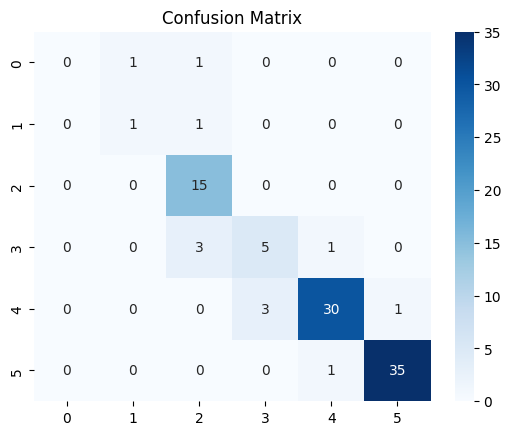

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.50      0.50         2
           2       0.75      1.00      0.86        15
           3       0.62      0.56      0.59         9
           4       0.94      0.88      0.91        34
           5       0.97      0.97      0.97        36

    accuracy                           0.88        98
   macro avg       0.63      0.65      0.64        98
weighted avg       0.86      0.88      0.87        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
recall_score(y_test, model.predict(x_test), average='weighted')

0.8775510204081632

In [ ]:
new_df = pd.DataFrame({'Actual': y_test, 'Predicted': pred})
new_df.head()

,Actual,Predicted
460,4,4
84,5,5
443,5,5
483,4,5
437,5,5


Model 2: SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC( C=10 ) ##  ويقلل الاخطاءRegularization  يتحكم في ال :(c)
svm.fit(x_train, y_train)

svm_pred = svm.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8979591836734694


Model 3: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, # هنا انا زودت عدد الاشجار
    max_depth=10  ## عمق الشجرة
)
rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9489795918367347


Text(0.5, 1.0, 'Feature Importance')

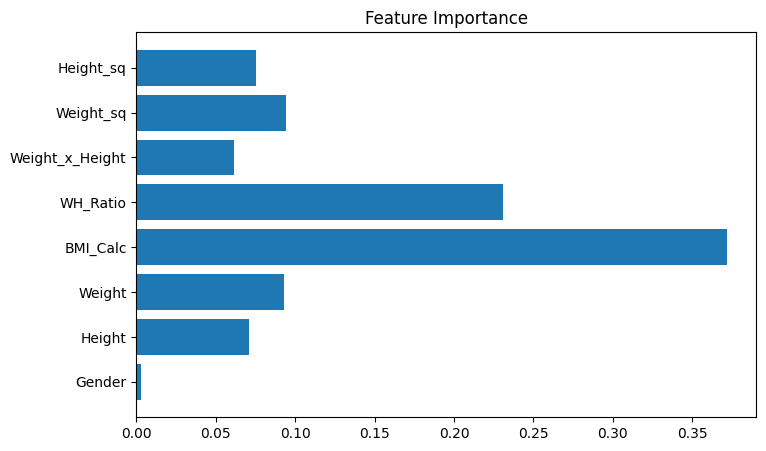

In [ ]:
importances = rf.feature_importances_
features = x.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance")

Model Comparison

In [ ]:
log_acc = accuracy_score(y_test, pred)
svm_acc = accuracy_score(y_test, svm_pred)
rf_acc = accuracy_score(y_test, rf_pred)

In [ ]:
models = ['Logistic Regression', 'SVM', 'Random Forest']
accuracies = [log_acc, svm_acc, rf_acc]

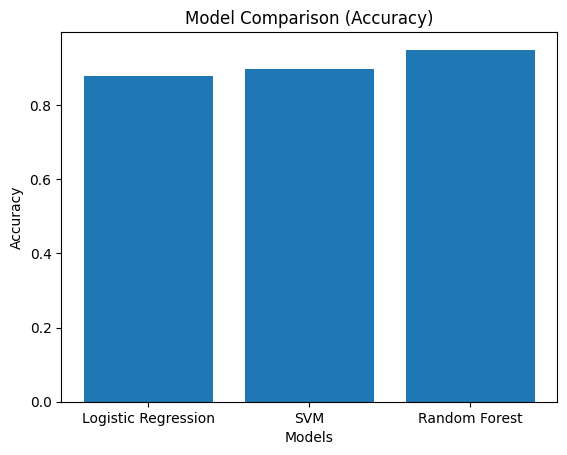

In [ ]:
plt.figure()
plt.bar(models, accuracies)

plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [181]:
## عدد كل فئة الموديل اتوقعها
pd.Series(pred).value_counts()

,count
5,36
4,32
2,20
3,8
1,2


In [184]:
## عدد كل فئة حقيقية
y_test.value_counts()


,count
Index,
5,36
4,34
2,15
3,9
1,2
0,2
